# Counter-Strike Professional Game Probability Regression Model

In [ ]:
# ── Standard Library ────────────────────────────────────────────────
import os
import random
import time

# ── Core Data ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import polars as pl

from dataclasses import dataclass
from typing import Dict, Callable, Tuple, Any

# ── Visualization ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Sklearn ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss, accuracy_score, f1_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# ── XGBoost ─────────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── PyCaret ─────────────────────────────────────────────────────────
from pycaret.classification import setup, compare_models, tune_model, predict_model, save_model

# ── PyTorch ─────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── Optuna ──────────────────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import logging

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

### Data Loading, Exploration And Cleanup

Data source: https://www.kaggle.com/datasets/gabrieltardochi/counter-strike-global-offensive-matches

In [50]:
def load_data(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    return pd.read_csv(path)

data_path = 'data/csgo_games.csv'

df = load_data(data_path)

In [51]:
df

,match_date,team_1,team_2,t1_points,t2_points,t1_world_rank,t2_world_rank,t1_h2h_win_perc,t2_h2h_win_perc,winner,...,t2_player5_dpr,t2_player5_spr,t2_player5_opk_ratio,t2_player5_opk_rating,t2_player5_wins_perc_after_fk,t2_player5_fk_perc_in_wins,t2_player5_multikill_perc,t2_player5_rating_at_least_one_perc,t2_player5_is_sniper,t2_player5_clutch_win_perc
0,2016-12-18,CLOUD9,HELLRAISERS,13,16,9,20,0.500000,0.500000,t2,...,0.63,0.10,1.05,0.92,0.733,0.104,0.147018,0.528,False,0.666667
1,2016-12-18,IMMORTALS,G2,17,19,13,10,0.500000,0.500000,t2,...,0.69,0.09,0.85,0.96,0.739,0.147,0.135810,0.438,True,0.406250
2,2016-12-18,MOUSESPORTS,IMMORTALS,16,3,12,13,0.500000,0.500000,t1,...,0.67,0.07,0.79,0.94,0.723,0.129,0.148257,0.526,False,0.733333
3,2016-12-18,DIGNITAS,G2,16,9,6,10,0.416667,0.583333,t1,...,0.69,0.09,0.85,0.96,0.739,0.147,0.135810,0.438,True,0.406250
4,2016-12-18,OPTIC,HELLRAISERS,16,10,4,20,0.500000,0.500000,t1,...,0.63,0.10,1.05,0.92,0.733,0.104,0.147018,0.528,False,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3782,2020-01-25,VIRTUS.PRO,CLOUD9,0,2,19,17,0.500000,0.500000,t2,...,0.67,0.11,0.80,0.95,0.681,0.121,0.130481,0.444,False,0.777778
3783,2020-01-24,HEROIC,MAD LIONS,10,16,16,18,0.333333,0.666667,t2,...,0.65,0.08,0.64,0.80,0.811,0.082,0.095975,0.250,False,0.625000
3784,2020-01-19,HEROIC,FORZE,0,2,16,13,0.857143,0.142857,t2,...,0.63,0.09,0.89,0.92,0.747,0.113,0.154618,0.635,False,0.709677
3785,2020-01-19,CR4ZY,FORZE,0,2,20,13,0.538462,0.461538,t2,...,0.63,0.09,0.89,0.92,0.747,0.113,0.154618,0.635,False,0.709677


In [52]:
df.shape

(3787, 170)

In [53]:
df.describe()

,t1_points,t2_points,t1_world_rank,t2_world_rank,t1_h2h_win_perc,t2_h2h_win_perc,t1_player1_rating,t1_player1_impact,t1_player1_kdr,t1_player1_dmr,...,t2_player5_apr,t2_player5_dpr,t2_player5_spr,t2_player5_opk_ratio,t2_player5_opk_rating,t2_player5_wins_perc_after_fk,t2_player5_fk_perc_in_wins,t2_player5_multikill_perc,t2_player5_rating_at_least_one_perc,t2_player5_clutch_win_perc
count,3787.000000,3787.000000,3787.000000,3787.000000,3787.000000,3787.000000,3787.000000,3787.000000,3787.000000,3787.000000,...,3787.000000,3787.000000,3787.000000,3787.000000,3787.000000,3786.000000,3787.000000,3787.000000,3787.000000,3787.000000
mean,7.829945,7.687351,8.836810,9.836546,0.517780,0.482220,1.185255,1.230552,1.211069,82.257882,...,0.134177,0.668492,0.085883,0.881109,0.933752,0.743385,0.123172,0.142620,0.479368,0.593293
std,6.869174,6.894263,5.550307,5.616128,0.228813,0.228813,0.067781,0.106033,0.112633,4.527635,...,0.019367,0.034841,0.015337,0.174513,0.072848,0.048824,0.025787,0.015386,0.099792,0.143225
min,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.970000,0.880000,0.870000,63.200000,...,0.040000,0.530000,0.020000,0.000000,0.490000,0.375000,0.000000,0.059829,0.000000,0.000000
25%,2.000000,2.000000,4.000000,5.000000,0.389566,0.333333,1.140000,1.160000,1.130000,79.200000,...,0.120000,0.650000,0.080000,0.770000,0.890000,0.715250,0.105000,0.132526,0.417000,0.500000
50%,6.000000,5.000000,8.000000,10.000000,0.500000,0.500000,1.180000,1.230000,1.200000,82.400000,...,0.130000,0.670000,0.090000,0.870000,0.930000,0.747000,0.121000,0.143365,0.483000,0.600000
75%,16.000000,16.000000,13.000000,15.000000,0.666667,0.610434,1.230000,1.300000,1.270000,85.300000,...,0.150000,0.690000,0.100000,0.980000,0.980000,0.775000,0.139000,0.152723,0.544000,0.676471
max,34.000000,34.000000,22.000000,22.000000,1.000000,1.000000,1.440000,1.790000,1.600000,98.700000,...,0.210000,0.810000,0.150000,2.120000,1.200000,1.000000,0.221000,0.194529,0.802000,1.000000


In [54]:
df[df.isnull().any(axis=1)]

,match_date,team_1,team_2,t1_points,t2_points,t1_world_rank,t2_world_rank,t1_h2h_win_perc,t2_h2h_win_perc,winner,...,t2_player5_dpr,t2_player5_spr,t2_player5_opk_ratio,t2_player5_opk_rating,t2_player5_wins_perc_after_fk,t2_player5_fk_perc_in_wins,t2_player5_multikill_perc,t2_player5_rating_at_least_one_perc,t2_player5_is_sniper,t2_player5_clutch_win_perc
383,2016-09-14,ENVY,MOUSESPORTS,9,16,11,16,0.461538,0.538462,t2,...,0.72,0.11,0.74,0.90,0.755,0.127,0.134255,0.400,False,0.538462
731,2016-03-31,MOUSESPORTS,NIP,1,2,10,9,0.153846,0.846154,t2,...,0.72,0.05,0.00,0.49,NaN,0.000,0.070175,0.000,False,1.000000
735,2016-03-30,NIP,LUMINOSITY,5,16,9,4,0.600000,0.400000,t2,...,0.63,0.08,0.93,0.97,0.764,0.120,0.168067,0.557,False,0.681818
1994,2018-11-13,HEROIC,HELLRAISERS,14,16,19,15,1.000000,0.000000,t2,...,0.68,0.09,0.79,0.89,0.693,0.108,0.121581,0.300,False,0.565217


#### Only 4 matches have missing values, can safely drop without thinking about filling strategies

In [55]:
df = df.dropna()

df.shape

(3783, 170)

In [56]:
df['winner'].value_counts()

winner
t1      1921
t2      1838
draw      24
Name: count, dtype: int64

24 Matches were draws, lets delete them (draws happen only in special situations, we dont want to predict them)

In [57]:
df = df[df['winner'].isin(['t1', 't2'])]

df['winner'].value_counts()

winner
t1    1921
t2    1838
Name: count, dtype: int64

### Leakage Check

We need to delete anything that is avaiable only POST game and is not the target, e.g. game points. We will also be deleting columns that don't bring any valuable information.

- date: not a usefull info
- team names: rosters change, models performance would worsen over time quicker
- points: not avaiable pre-match
- leaving player ratings as they are calculated over a 3 month period BEFORE the game

In [58]:
# manually inspecting each column :(((
for col in df.columns:
    print(col)
    

match_date
team_1
team_2
t1_points
t2_points
t1_world_rank
t2_world_rank
t1_h2h_win_perc
t2_h2h_win_perc
winner
t1_player1_rating
t1_player1_impact
t1_player1_kdr
t1_player1_dmr
t1_player1_kpr
t1_player1_apr
t1_player1_dpr
t1_player1_spr
t1_player1_opk_ratio
t1_player1_opk_rating
t1_player1_wins_perc_after_fk
t1_player1_fk_perc_in_wins
t1_player1_multikill_perc
t1_player1_rating_at_least_one_perc
t1_player1_is_sniper
t1_player1_clutch_win_perc
t1_player2_rating
t1_player2_impact
t1_player2_kdr
t1_player2_dmr
t1_player2_kpr
t1_player2_apr
t1_player2_dpr
t1_player2_spr
t1_player2_opk_ratio
t1_player2_opk_rating
t1_player2_wins_perc_after_fk
t1_player2_fk_perc_in_wins
t1_player2_multikill_perc
t1_player2_rating_at_least_one_perc
t1_player2_is_sniper
t1_player2_clutch_win_perc
t1_player3_rating
t1_player3_impact
t1_player3_kdr
t1_player3_dmr
t1_player3_kpr
t1_player3_apr
t1_player3_dpr
t1_player3_spr
t1_player3_opk_ratio
t1_player3_opk_rating
t1_player3_wins_perc_after_fk
t1_player3_fk_per

In [59]:
del_cols_keywords = ['date', 'team_1', 'team_2', 'points']

# dropping the cols
df = df.drop(columns=[col for col in df.columns if any(keyword in col for keyword in del_cols_keywords)])

df.columns

Index(['t1_world_rank', 't2_world_rank', 't1_h2h_win_perc', 't2_h2h_win_perc',
       'winner', 't1_player1_rating', 't1_player1_impact', 't1_player1_kdr',
       't1_player1_dmr', 't1_player1_kpr',
       ...
       't2_player5_dpr', 't2_player5_spr', 't2_player5_opk_ratio',
       't2_player5_opk_rating', 't2_player5_wins_perc_after_fk',
       't2_player5_fk_perc_in_wins', 't2_player5_multikill_perc',
       't2_player5_rating_at_least_one_perc', 't2_player5_is_sniper',
       't2_player5_clutch_win_perc'],
      dtype='object', length=165)

Turning str map winner into numerical

In [60]:
df['winner'] = df['winner'].map({'t1': 0, 't2': 1})

### Checking Variances and Correlations
Can drop low variance columns and one column of a highly correlated pair

In [61]:
num_df = df.select_dtypes(include="number")

num_df.var().sort_values(ascending=True)


t1_player3_multikill_perc     0.000184
t2_player3_multikill_perc     0.000188
t2_player2_multikill_perc     0.000190
t2_player4_multikill_perc     0.000193
t1_player4_multikill_perc     0.000194
                               ...    
t1_player2_dmr               18.786694
t1_player1_dmr               20.507937
t2_player1_dmr               22.377729
t1_world_rank                30.801200
t2_world_rank                31.560514
Length: 155, dtype: float64

In [62]:
corr = num_df.corr()

mask = np.triu(np.ones(corr.shape), k=1).astype(bool)

pairs = (
corr.where(mask)
.stack()
.reset_index()
)
pairs.columns = ["col_1", "col_2", "corr"]

pairs["abs_corr"] = pairs["corr"].abs()
pairs = pairs.sort_values("abs_corr", ascending=False).reset_index(drop=True)

pairs

,col_1,col_2,corr,abs_corr
0,t1_h2h_win_perc,t2_h2h_win_perc,-1.000000,1.000000
1,t1_player1_kpr,t1_player1_multikill_perc,0.923903,0.923903
2,t2_player1_kpr,t2_player1_multikill_perc,0.923774,0.923774
3,t2_player5_kpr,t2_player5_multikill_perc,0.915377,0.915377
4,t1_player5_kpr,t1_player5_multikill_perc,0.912446,0.912446
...,...,...,...,...
11930,t1_player3_fk_perc_in_wins,t2_player1_fk_perc_in_wins,0.000009,0.000009
11931,t1_player3_apr,t2_player3_apr,0.000008,0.000008
11932,t2_player2_wins_perc_after_fk,t2_player3_spr,0.000005,0.000005
11933,t1_player4_impact,t2_player5_wins_perc_after_fk,0.000004,0.000004


Dropping Team 2 head to head win percentage as its just 1 - t1_h2h_win_perc. Will leave highly correlated player stats (a good player will have good stats across the board) as it shouldn't negatively impact nets or xgboost, although will prepare a simple data version with just player rating (some unknown combination of all the stats) as it might work better for simple models (e.g lin reg).

In [63]:
df = df.drop(columns=['t2_h2h_win_perc'])

Computing world rank diff

In [64]:

df['world_rank_diff'] = df['t1_world_rank'] - df['t2_world_rank']

df[['world_rank_diff', 't1_world_rank', 't2_world_rank']].head()

,world_rank_diff,t1_world_rank,t2_world_rank
0,-11,9,20
1,3,13,10
2,-1,12,13
3,-4,6,10
4,-16,4,20


In [65]:
leave_cols_keywords = ['world_rank', 't1_h2h_win_perc', 'winner', 'rating']
remove_cols_keywords = ['rating_at_least_one_perc', 'opk_rating']

df_simple = df[[col for col in df.columns if any(keyword in col for keyword in leave_cols_keywords) and not any(keyword in col for keyword in remove_cols_keywords)]]

simple_cols = list(df_simple.columns)
simple_cols

['t1_world_rank',
 't2_world_rank',
 't1_h2h_win_perc',
 'winner',
 't1_player1_rating',
 't1_player2_rating',
 't1_player3_rating',
 't1_player4_rating',
 't1_player5_rating',
 't2_player1_rating',
 't2_player2_rating',
 't2_player3_rating',
 't2_player4_rating',
 't2_player5_rating',
 'world_rank_diff']

<Axes: >

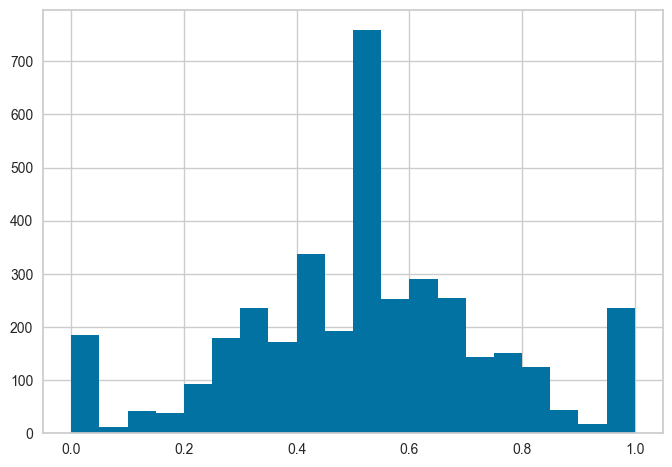

In [66]:
df['t1_h2h_win_perc'].hist(bins=20)

t1_h2h_win_perc might be a problematic feature, teams that faced each other only once will have either 1.0 or 0.0 which is an unreasonably strong signal. There is no info about the number of matches between them. Solution: prepare different versions and include them in the hyperparam search.

### Creating a holdout Test set

In [67]:
TARGET_COL = "winner"
H2H_COL = "t1_h2h_win_perc"
SEED = 42

In [68]:
# All columns confirmed to be valid dtypes

train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=SEED,
    stratify=df[TARGET_COL],
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df.shape, test_df.shape

((3195, 165), (564, 165))

In [69]:
def make_h2h_versions(df: pd.DataFrame, h2h_col: str = H2H_COL) -> Dict[str, pd.DataFrame]:
    out: Dict[str, pd.DataFrame] = {}

    out["raw"] = df.copy()

    d = df.copy()
    if h2h_col in d.columns:
        d = d.drop(columns=[h2h_col])
    out["drop"] = d

    d = df.copy()
    if h2h_col in d.columns:
        d[h2h_col] = d[h2h_col].astype(float).clip(0.05, 0.95)
    out["clip_05_95"] = d

    d = df.copy()
    if h2h_col in d.columns:
        d[h2h_col] = d[h2h_col].astype(float).clip(0.10, 0.90)
    out["clip_10_90"] = d

    d = df.copy()
    if h2h_col in d.columns:
        p = d[h2h_col].astype(float)
        d["h2h_signed"] = p - 0.5
        d["h2h_abs_strength"] = (p - 0.5).abs()
        d["h2h_is_extreme"] = ((p <= 0.01) | (p >= 0.99)).astype(int)
        d = d.drop(columns=[h2h_col])
    out["signed_extreme"] = d

    return out

def build_cv_dataset_variants(
    base_datasets: Dict[str, pd.DataFrame],
    target_col: str = TARGET_COL,
    h2h_col: str = H2H_COL,
) -> Tuple[Dict[str, Dict[str, Any]], pd.DataFrame]:
    cv_ready: Dict[str, Dict[str, Any]] = {}
    rows = []

    for base_name, base_df in base_datasets.items():
        h2h_versions = make_h2h_versions(base_df, h2h_col=h2h_col)

        for h2h_name, d in h2h_versions.items():
            name = f"{base_name}__h2h_{h2h_name}"
            d = d.dropna(subset=[target_col]).reset_index(drop=True)

            X = d.drop(columns=[target_col]).copy()
            y = d[target_col].astype(int).copy()

            # Normalize bool features so all estimators see numeric values.
            bool_cols = X.select_dtypes(include=["bool"]).columns
            if len(bool_cols) > 0:
                X[bool_cols] = X[bool_cols].astype(int)

            cv_ready[name] = {
                "df": d,
                "X": X,
                "y": y,
            }

            rows.append(
                {
                    "dataset_name": name,
                    "rows": len(d),
                    "feature_cols": X.shape[1],
                    "has_h2h_raw": h2h_col in d.columns,
                    "pos_rate": float(y.mean()),
                }
            )

    manifest = pd.DataFrame(rows).sort_values("dataset_name").reset_index(drop=True)
    return cv_ready, manifest

simple_train = train_df[simple_cols].copy()
simple_test = test_df[simple_cols].copy()

base_datasets_train_cv = {
    "full": train_df,
    "simple": simple_train,
}

base_datasets_test = {
    "full": test_df,
    "simple": simple_test,
}

cv_variants, cv_manifest = build_cv_dataset_variants(base_datasets_train_cv)
test_variants, test_manifest = build_cv_dataset_variants(base_datasets_test)

# safety check
assert set(cv_variants.keys()) == set(test_variants.keys())

print("holdout_split_shapes:", simple_test.shape, test_df.shape)
print("cv_variant_count:", len(cv_variants), "test_variant_count:", len(test_variants))
cv_manifest.head(10)

holdout_split_shapes: (564, 15) (564, 165)
cv_variant_count: 10 test_variant_count: 10


,dataset_name,rows,feature_cols,has_h2h_raw,pos_rate
0,full__h2h_clip_05_95,3195,164,True,0.488889
1,full__h2h_clip_10_90,3195,164,True,0.488889
2,full__h2h_drop,3195,163,False,0.488889
3,full__h2h_raw,3195,164,True,0.488889
4,full__h2h_signed_extreme,3195,166,False,0.488889
5,simple__h2h_clip_05_95,3195,14,True,0.488889
6,simple__h2h_clip_10_90,3195,14,True,0.488889
7,simple__h2h_drop,3195,13,False,0.488889
8,simple__h2h_raw,3195,14,True,0.488889
9,simple__h2h_signed_extreme,3195,16,False,0.488889


In [75]:
variant_name = "full__h2h_raw"
simple_variant_name = "simple__h2h_raw"

X_train = cv_variants[variant_name]["X"].copy()
y_train = cv_variants[variant_name]["y"].astype(int).copy()
X_test = test_variants[variant_name]["X"].copy()
y_test = test_variants[variant_name]["y"].astype(int).copy()

X_train_simple = cv_variants[simple_variant_name]["X"].copy()
y_train_simple = cv_variants[simple_variant_name]["y"].astype(int).copy()
X_test_simple = test_variants[simple_variant_name]["X"].copy()
y_test_simple = test_variants[simple_variant_name]["y"].astype(int).copy()

# baseline 1: higher rank wins
t1_rank = X_test["t1_world_rank"].to_numpy()
t2_rank = X_test["t2_world_rank"].to_numpy()
p_rank = np.where(t1_rank < t2_rank, 0.0, np.where(t2_rank < t1_rank, 1.0, 0.5)).astype(float)

# baseline 2: linear regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
p_lin = lin_reg.predict(X_test)
p_lin = np.clip(p_lin, 0.0, 1.0)

# baseline 3: linear regression on simple features only
lin_reg_simple = LinearRegression()
lin_reg_simple.fit(X_train_simple, y_train_simple)
p_lin_simple = lin_reg_simple.predict(X_test_simple)
p_lin_simple = np.clip(p_lin_simple, 0.0, 1.0)

# baseline 4: random forest regressor on all features
rf_reg = RandomForestRegressor(
    n_estimators=400,
    random_state=SEED,
    n_jobs=-1,
    min_samples_leaf=5,
)

rf_reg.fit(X_train, y_train)
p_rf = rf_reg.predict(X_test)
p_rf = np.clip(p_rf, 0.0, 1.0)

# baseline 5: random forest on simple features only
rf_reg_simple = RandomForestRegressor(
    n_estimators=400,
    random_state=SEED,
    n_jobs=-1,
    min_samples_leaf=5,
)
rf_reg_simple.fit(X_train_simple, y_train_simple)
p_rf_simple = rf_reg_simple.predict(X_test_simple)
p_rf_simple = np.clip(p_rf_simple, 0.0, 1.0)

# baseline 6: XGBoost on all features
xgb_clf = XGBClassifier(
    n_estimators=400,
    random_state=SEED,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric="logloss",
)
xgb_clf.fit(X_train, y_train)
p_xgb = xgb_clf.predict_proba(X_test)[:, 1]

# baseline 7: XGBoost on simple features only
xgb_clf_simple = XGBClassifier(
    n_estimators=400,
    random_state=SEED,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric="logloss",
)
xgb_clf_simple.fit(X_train_simple, y_train_simple)
p_xgb_simple = xgb_clf_simple.predict_proba(X_test_simple)[:, 1]

# evaluation
# 
# brier score (primary)
# log loss
# roc auc
# accuracy and f1 at 0.5 threshold (>0.5 -> t2 wins, <0.5 -> t1 wins)

rows = []
for model_name, p in [
    ("rank_baseline", p_rank),
    ("linear_regression", p_lin),
    ("random_forest_reg", p_rf),
    ("linear_regression_simple", p_lin_simple),
    ("random_forest_reg_simple", p_rf_simple),
    ("xgboost", p_xgb),
    ("xgboost_simple", p_xgb_simple),
]:
    pred_label = (p >= 0.5).astype(int)

    rows.append(
        {
            "model": model_name,
            "brier": brier_score_loss(y_test, p),
            "log_loss": log_loss(y_test, p, labels=[0, 1]),
            "roc_auc": roc_auc_score(y_test, p),
            "accuracy@0.5": accuracy_score(y_test, pred_label),
            "f1@0.5": f1_score(y_test, pred_label),
            "mean_pred_prob_t2": float(np.mean(p)),
        }
    )

results = pd.DataFrame(rows).sort_values(["brier", "log_loss"], ascending=[True, True]).reset_index(drop=True)
results

,model,brier,log_loss,roc_auc,accuracy@0.5,f1@0.5,mean_pred_prob_t2
0,linear_regression_simple,0.231000,0.653801,0.662175,0.624113,0.595420,0.482433
1,random_forest_reg_simple,0.235467,0.664275,0.638763,0.586879,0.564486,0.482574
2,random_forest_reg,0.238483,0.670354,0.628195,0.593972,0.565465,0.484693
3,linear_regression,0.245948,0.746183,0.603972,0.578014,0.552632,0.478482
4,xgboost_simple,0.312383,0.999040,0.595725,0.554965,0.542805,0.474457
5,xgboost,0.332998,1.156900,0.583711,0.558511,0.552962,0.484682
6,rank_baseline,0.404255,14.570839,0.594203,0.595745,0.558140,0.425532


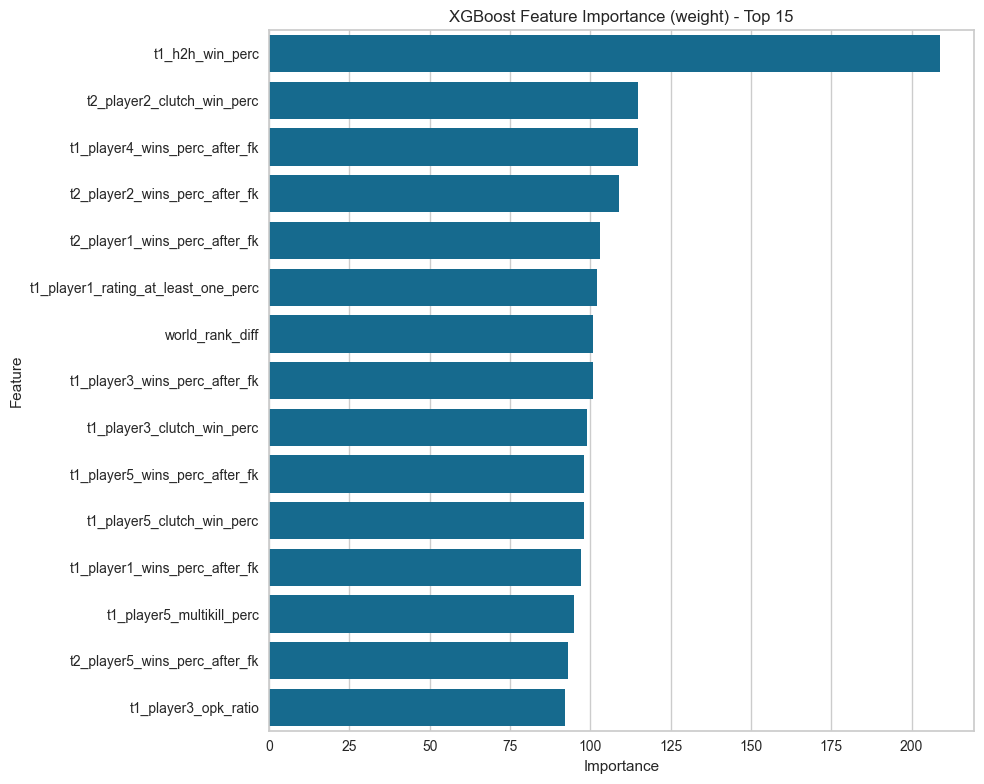

In [74]:
importance_type = "weight"
top_n = 15

booster = xgb_clf.get_booster()
scores = booster.get_score(importance_type=importance_type)

imp_df = (
    pd.DataFrame(scores.items(), columns=["feature", "importance"])
    .sort_values("importance", ascending=False)
    .head(top_n)
)

plt.figure(figsize=(10, 8))
sns.barplot(data=imp_df, x="importance", y="feature", orient="h")
plt.title(f"XGBoost Feature Importance ({importance_type}) - Top {top_n}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Beating baseline with Neural Nets
Now we will be trying to beat the briar score of 0.2310 and the accuracy of 0.6241 with neural networks.

In [ ]:
n_trials_per_variant = 35
max_epochs = 140
patience = 14
search_timeout_per_variant = None
top_k_refit = 5

if torch.backends.mps.is_available():
    RUN_DEVICE = torch.device("mps")

# Logger
logger = logging.getLogger("dnn_global_search")
if not logger.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter("[%(asctime)s] %(message)s", datefmt="%H:%M:%S"))
    logger.addHandler(handler)
logger.setLevel(logging.INFO)

logger.info("=== GLOBAL DNN SEARCH START ===")
logger.info(f"device={RUN_DEVICE}")
logger.info(
    f"config: trials_per_variant={n_trials_per_variant}, max_epochs={max_epochs}, "
    f"patience={patience}, timeout_per_variant={search_timeout_per_variant}"
)

variant_names = sorted(cv_variants.keys())
logger.info(f"variants={len(variant_names)}")


class DNNFlexible(nn.Module):
    def __init__(self, in_dim, hidden_dims, dropout):
        super().__init__()
        layers = []
        d = in_dim
        for h in hidden_dims:
            layers.append(nn.Linear(d, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            d = h
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


def build_hidden_dims(base_width, n_layers, width_decay):
    dims = []
    w = float(base_width)
    for _ in range(n_layers):
        dims.append(max(16, int(round(w))))
        w = w * width_decay
    return dims


search_rows = []
holdout_rows = []

for variant_name in variant_names:
    logger.info(f"--- Variant: {variant_name} ---")
    variant_start = time.perf_counter()

    # Data
    X_cv = cv_variants[variant_name]["X"].copy()
    y_cv = cv_variants[variant_name]["y"].astype(int).copy()
    X_test = test_variants[variant_name]["X"].copy()
    y_test = test_variants[variant_name]["y"].astype(int).copy()

    # Bool -> int
    bool_cols_cv = X_cv.select_dtypes(include=["bool"]).columns
    if len(bool_cols_cv) > 0:
        X_cv[bool_cols_cv] = X_cv[bool_cols_cv].astype(int)

    bool_cols_test = X_test.select_dtypes(include=["bool"]).columns
    if len(bool_cols_test) > 0:
        X_test[bool_cols_test] = X_test[bool_cols_test].astype(int)

    # Train/val split for search
    X_train_df, X_val_df, y_train_s, y_val_s = train_test_split(
        X_cv,
        y_cv,
        test_size=0.20,
        random_state=SEED,
        stratify=y_cv,
    )

    # Scale for DNN
    scaler_search = StandardScaler()
    X_train_np = scaler_search.fit_transform(X_train_df).astype(np.float32)
    X_val_np = scaler_search.transform(X_val_df).astype(np.float32)

    y_train_np = y_train_s.values.astype(np.float32)
    y_val_np = y_val_s.values.astype(np.float32)

    X_train_t = torch.tensor(X_train_np, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_np, dtype=torch.float32)
    X_val_t = torch.tensor(X_val_np, dtype=torch.float32)

    input_dim = X_train_t.shape[1]

    def objective(trial):
        base_width = trial.suggest_categorical("base_width", [64, 128, 256, 384, 512, 768, 1024])
        n_layers = trial.suggest_int("n_layers", 1, 6)
        width_decay = trial.suggest_categorical("width_decay", [1.0, 0.85, 0.70, 0.55])
        dropout = trial.suggest_float("dropout", 0.0, 0.5)

        lr = trial.suggest_float("lr", 5e-5, 5e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-8, 1e-3, log=True)
        batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])

        hidden_dims = build_hidden_dims(base_width, n_layers, width_decay)

        model = DNNFlexible(input_dim, hidden_dims, dropout).to(RUN_DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        criterion = nn.BCEWithLogitsLoss()

        train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t)
        train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)

        Xv = X_val_t.to(RUN_DEVICE)

        best_brier = np.inf
        best_epoch = 1
        wait = 0
        t0 = time.perf_counter()

        for epoch in range(1, max_epochs + 1):
            model.train()
            for xb, yb in train_loader:
                xb = xb.to(RUN_DEVICE)
                yb = yb.to(RUN_DEVICE)

                optimizer.zero_grad()
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()

            model.eval()
            with torch.no_grad():
                val_probs = torch.sigmoid(model(Xv)).cpu().numpy()
                val_brier = brier_score_loss(y_val_np, val_probs)

            trial.report(val_brier, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

            if val_brier < best_brier:
                best_brier = val_brier
                best_epoch = epoch
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    break

        trial.set_user_attr("best_epoch", best_epoch)
        trial.set_user_attr("trial_seconds", time.perf_counter() - t0)
        trial.set_user_attr("hidden_dims", hidden_dims)
        return best_brier

    study = optuna.create_study(
        direction="minimize",
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    )

    study.optimize(
        objective,
        n_trials=n_trials_per_variant,
        timeout=search_timeout_per_variant,
        show_progress_bar=False,
    )

    variant_search_sec = time.perf_counter() - variant_start
    best = study.best_params
    best_epoch = study.best_trial.user_attrs.get("best_epoch", max(2, max_epochs // 2))
    hidden_dims = study.best_trial.user_attrs.get("hidden_dims", [best.get("base_width", 64)])

    search_rows.append(
        {
            "variant": variant_name,
            "best_val_brier": float(study.best_value),
            "best_trial": int(study.best_trial.number),
            "n_trials_done": len(study.trials),
            "best_epoch": int(best_epoch),
            "hidden_dims": str(hidden_dims),
            "best_params": str(best),
            "search_seconds": float(variant_search_sec),
        }
    )

    logger.info(
        f"Variant done: {variant_name} | val_brier={study.best_value:.5f} | "
        f"trials={len(study.trials)} | best_epoch={best_epoch} | time={variant_search_sec/60:.2f} min"
    )

# rank by brier
search_df = pd.DataFrame(search_rows).sort_values("best_val_brier").reset_index(drop=True)
display(search_df)

# refit top variants on full CV
top_variants = search_df.head(top_k_refit)["variant"].tolist()
logger.info(f"Refitting top variants on full CV: {top_variants}")

for variant_name in top_variants:
    row = search_df[search_df["variant"] == variant_name].iloc[0]
    best_epoch = int(row["best_epoch"])

    # Recover params from string safely
    best_params = eval(row["best_params"], {"__builtins__": {}}, {})
    hidden_dims = eval(row["hidden_dims"], {"__builtins__": {}}, {})

    X_cv = cv_variants[variant_name]["X"].copy()
    y_cv = cv_variants[variant_name]["y"].astype(int).copy()
    X_test = test_variants[variant_name]["X"].copy()
    y_test = test_variants[variant_name]["y"].astype(int).copy()

    bool_cols_cv = X_cv.select_dtypes(include=["bool"]).columns
    if len(bool_cols_cv) > 0:
        X_cv[bool_cols_cv] = X_cv[bool_cols_cv].astype(int)

    bool_cols_test = X_test.select_dtypes(include=["bool"]).columns
    if len(bool_cols_test) > 0:
        X_test[bool_cols_test] = X_test[bool_cols_test].astype(int)

    scaler_final = StandardScaler()
    X_cv_np = scaler_final.fit_transform(X_cv).astype(np.float32)
    X_test_np = scaler_final.transform(X_test).astype(np.float32)

    y_cv_np = y_cv.values.astype(np.float32)
    y_test_np = y_test.values.astype(np.float32)

    X_cv_t = torch.tensor(X_cv_np, dtype=torch.float32)
    y_cv_t = torch.tensor(y_cv_np, dtype=torch.float32)
    X_test_t = torch.tensor(X_test_np, dtype=torch.float32)

    model = DNNFlexible(
        in_dim=X_cv_t.shape[1],
        hidden_dims=hidden_dims,
        dropout=float(best_params["dropout"]),
    ).to(RUN_DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=float(best_params["lr"]),
        weight_decay=float(best_params["weight_decay"]),
    )
    criterion = nn.BCEWithLogitsLoss()

    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_cv_t, y_cv_t),
        batch_size=int(best_params["batch_size"]),
        shuffle=True,
    )

    t0 = time.perf_counter()
    for _ in range(best_epoch):
        model.train()
        for xb, yb in loader:
            xb = xb.to(RUN_DEVICE)
            yb = yb.to(RUN_DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
    fit_sec = time.perf_counter() - t0

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_test_t.to(RUN_DEVICE))).cpu().numpy()

    probs = np.clip(probs, 1e-6, 1 - 1e-6)
    pred = (probs >= 0.5).astype(int)

    holdout_rows.append(
        {
            "model": f"dnn_global_{variant_name}",
            "variant": variant_name,
            "brier": brier_score_loss(y_test_np, probs),
            "log_loss": log_loss(y_test_np, probs, labels=[0, 1]),
            "roc_auc": roc_auc_score(y_test_np, probs),
            "accuracy@0.5": accuracy_score(y_test_np, pred),
            "f1@0.5": f1_score(y_test_np, pred),
            "mean_pred_prob_t2": float(np.mean(probs)),
            "best_epoch": best_epoch,
            "fit_seconds": fit_sec,
        }
    )

holdout_df = pd.DataFrame(holdout_rows).sort_values(["brier", "log_loss"]).reset_index(drop=True)
display(holdout_df)

if "results" in globals():
    display(
        pd.concat([results, holdout_df], ignore_index=True)
        .sort_values(["brier", "log_loss"])
        .reset_index(drop=True)
    )

logger.info("=== GLOBAL DNN SEARCH END ===")

[21:15:16] === GLOBAL DNN SEARCH START ===
[21:15:16] device=mps
[21:15:16] config: trials_per_variant=35, max_epochs=140, patience=14, timeout_per_variant=None, smoke=False
[21:15:16] variants=10
[21:15:16] --- Variant: full__h2h_clip_05_95 ---
[21:16:36] Variant done: full__h2h_clip_05_95 | val_brier=0.23987 | trials=35 | best_epoch=4 | time=1.34 min
[21:16:36] --- Variant: full__h2h_clip_10_90 ---
[21:18:07] Variant done: full__h2h_clip_10_90 | val_brier=0.23761 | trials=35 | best_epoch=4 | time=1.51 min
[21:18:07] --- Variant: full__h2h_drop ---
[21:19:53] Variant done: full__h2h_drop | val_brier=0.23971 | trials=35 | best_epoch=5 | time=1.77 min
[21:19:53] --- Variant: full__h2h_raw ---
[21:21:16] Variant done: full__h2h_raw | val_brier=0.23983 | trials=35 | best_epoch=4 | time=1.37 min
[21:21:16] --- Variant: full__h2h_signed_extreme ---
[21:22:19] Variant done: full__h2h_signed_extreme | val_brier=0.23953 | trials=35 | best_epoch=3 | time=1.06 min
[21:22:19] --- Variant: simple_

,variant,best_val_brier,best_trial,n_trials_done,best_epoch,hidden_dims,best_params,search_seconds
0,simple__h2h_signed_extreme,0.235856,22,35,12,"[128, 90, 63, 44, 31, 22]","{'base_width': 128, 'n_layers': 6, 'width_deca...",72.033360
1,simple__h2h_raw,0.236654,8,35,18,"[384, 211, 116, 64, 35, 19]","{'base_width': 384, 'n_layers': 6, 'width_deca...",81.509147
2,simple__h2h_clip_05_95,0.236822,34,35,8,"[64, 35, 19, 16]","{'base_width': 64, 'n_layers': 4, 'width_decay...",59.626028
3,simple__h2h_drop,0.236831,31,35,5,"[64, 54, 46, 39, 33]","{'base_width': 64, 'n_layers': 5, 'width_decay...",93.972494
4,simple__h2h_clip_10_90,0.236913,26,35,4,"[256, 256, 256]","{'base_width': 256, 'n_layers': 3, 'width_deca...",82.485425
5,full__h2h_clip_10_90,0.237606,10,35,4,"[128, 70, 39, 21, 16, 16]","{'base_width': 128, 'n_layers': 6, 'width_deca...",90.530491
6,full__h2h_signed_extreme,0.239532,20,35,3,"[768, 653, 555]","{'base_width': 768, 'n_layers': 3, 'width_deca...",63.377591
7,full__h2h_drop,0.239715,22,35,5,"[256, 218, 185, 157, 134]","{'base_width': 256, 'n_layers': 5, 'width_deca...",106.425272
8,full__h2h_raw,0.239831,23,35,4,"[64, 64, 64, 64, 64]","{'base_width': 64, 'n_layers': 5, 'width_decay...",82.320787
9,full__h2h_clip_05_95,0.239874,9,35,4,"[64, 45, 31]","{'base_width': 64, 'n_layers': 3, 'width_decay...",80.441450


[21:28:49] Refitting top variants on full CV: ['simple__h2h_signed_extreme', 'simple__h2h_raw', 'simple__h2h_clip_05_95', 'simple__h2h_drop', 'simple__h2h_clip_10_90']


,model,variant,brier,log_loss,roc_auc,accuracy@0.5,f1@0.5,mean_pred_prob_t2,best_epoch,fit_seconds
0,dnn_global_simple__h2h_raw,simple__h2h_raw,0.231537,0.654936,0.658401,0.625887,0.626549,0.482500,18,1.853858
1,dnn_global_simple__h2h_clip_05_95,simple__h2h_clip_05_95,0.231621,0.655261,0.655986,0.620567,0.600746,0.495615,8,0.690039
2,dnn_global_simple__h2h_signed_extreme,simple__h2h_signed_extreme,0.231653,0.655327,0.657961,0.624113,0.610294,0.503154,12,2.185419
3,dnn_global_simple__h2h_clip_10_90,simple__h2h_clip_10_90,0.232163,0.656330,0.661056,0.615248,0.621291,0.501322,4,0.452188
4,dnn_global_simple__h2h_drop,simple__h2h_drop,0.237459,0.667716,0.650639,0.604610,0.618803,0.520387,5,1.561269


,model,brier,log_loss,roc_auc,accuracy@0.5,f1@0.5,mean_pred_prob_t2,variant,best_epoch,fit_seconds
0,linear_regression_simple,0.231000,0.653801,0.662175,0.624113,0.595420,0.482433,NaN,NaN,NaN
1,dnn_global_simple__h2h_raw,0.231537,0.654936,0.658401,0.625887,0.626549,0.482500,simple__h2h_raw,18.0,1.853858
2,dnn_global_simple__h2h_clip_05_95,0.231621,0.655261,0.655986,0.620567,0.600746,0.495615,simple__h2h_clip_05_95,8.0,0.690039
3,dnn_global_simple__h2h_signed_extreme,0.231653,0.655327,0.657961,0.624113,0.610294,0.503154,simple__h2h_signed_extreme,12.0,2.185419
4,dnn_global_simple__h2h_clip_10_90,0.232163,0.656330,0.661056,0.615248,0.621291,0.501322,simple__h2h_clip_10_90,4.0,0.452188
5,random_forest_reg_simple,0.235467,0.664275,0.638763,0.586879,0.564486,0.482574,NaN,NaN,NaN
6,dnn_global_simple__h2h_drop,0.237459,0.667716,0.650639,0.604610,0.618803,0.520387,simple__h2h_drop,5.0,1.561269
7,random_forest_reg,0.238483,0.670354,0.628195,0.593972,0.565465,0.484693,NaN,NaN,NaN
8,linear_regression,0.245948,0.746183,0.603972,0.578014,0.552632,0.478482,NaN,NaN,NaN
9,xgboost,0.332998,1.156900,0.583711,0.558511,0.552962,0.484682,NaN,NaN,NaN


[21:28:56] === GLOBAL DNN SEARCH END ===


## Conclusions and Findings

My best dnn model turned out to be performing simirarly to the baseline linear regression model trained on the smaller version of the dataset. Even the "higher ranked team wins" model performed pretty well in terms of accuracy (low brier score because it gets penalized for being overly confident).
Better models probably would be possible with a bigger and better dataset, however that would require data scraping and using libraries to extract information from the matches.
We could see improvments when adding live team information such as: do they have standings? is someone sick? etc.